In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmocean
import matplotlib.dates as mdates
# import datetime.datetime as datetime

In [2]:
# load the old and new flux files
base=pd.read_csv('/home/jisrael/BayDeltaSCHISM/data/time_history/flux.th',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
dcp_old=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/data/time_history/flux_s0065.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
dcp =pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/data/time_history/flux_dcp_fixed.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
cor_old=pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/reserves/data/time_history/flux_s0044.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
cor =pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/reserves/data/time_history/flux_cor_fixed.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])

base

,coyote,ccc_rock,ccc_old,swp,cvp,sjr,calaveras,east,american,sac,yolo_toedrain,yolo,northbay,napa,ccc_victoria
datetime,,,,,,,,,,,,,,,
2006-10-01 00:00:00,-0.62,0.67,4.52,262.320007,120.830002,-94.860001,-0.0,-25.780001,-72.769997,-329.829987,0.690000,-0.00,2.48,-0.01,0.00
2006-10-01 00:15:00,-0.62,0.67,4.52,263.239990,120.820000,-94.860001,-0.0,-25.730000,-71.919998,-329.890015,-4.620000,-0.00,2.46,-0.01,0.00
2006-10-01 00:30:00,-0.62,0.66,4.52,263.410004,120.820000,-95.430000,-0.0,-25.690001,-73.339996,-330.239990,-8.100000,-0.00,2.46,-0.01,0.00
2006-10-01 00:45:00,-0.62,0.66,4.52,263.390015,120.820000,-94.860001,-0.0,-25.660000,-73.910004,-330.299988,-9.660000,-0.00,2.45,-0.01,0.00
2006-10-01 01:00:00,-0.62,0.66,4.52,263.350006,120.820000,-94.860001,-0.0,-25.629999,-73.910004,-330.649994,-10.650000,-0.00,2.45,-0.01,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-14 23:00:00,-0.76,0.00,3.40,1.010000,98.879997,-79.940002,-0.0,-76.169998,-144.699997,-1716.310059,-113.269997,-9.06,0.54,-5.10,1.17
2026-01-14 23:15:00,-0.74,0.00,3.42,3.000000,98.870003,-79.919998,-0.0,-76.180000,-144.699997,-1716.869995,-113.269997,-8.50,0.55,-5.04,1.18
2026-01-14 23:30:00,-0.74,0.00,3.44,7.780000,98.860001,-79.900002,-0.0,-76.180000,-144.130005,-1716.869995,-113.269997,-8.50,0.57,-5.10,1.20


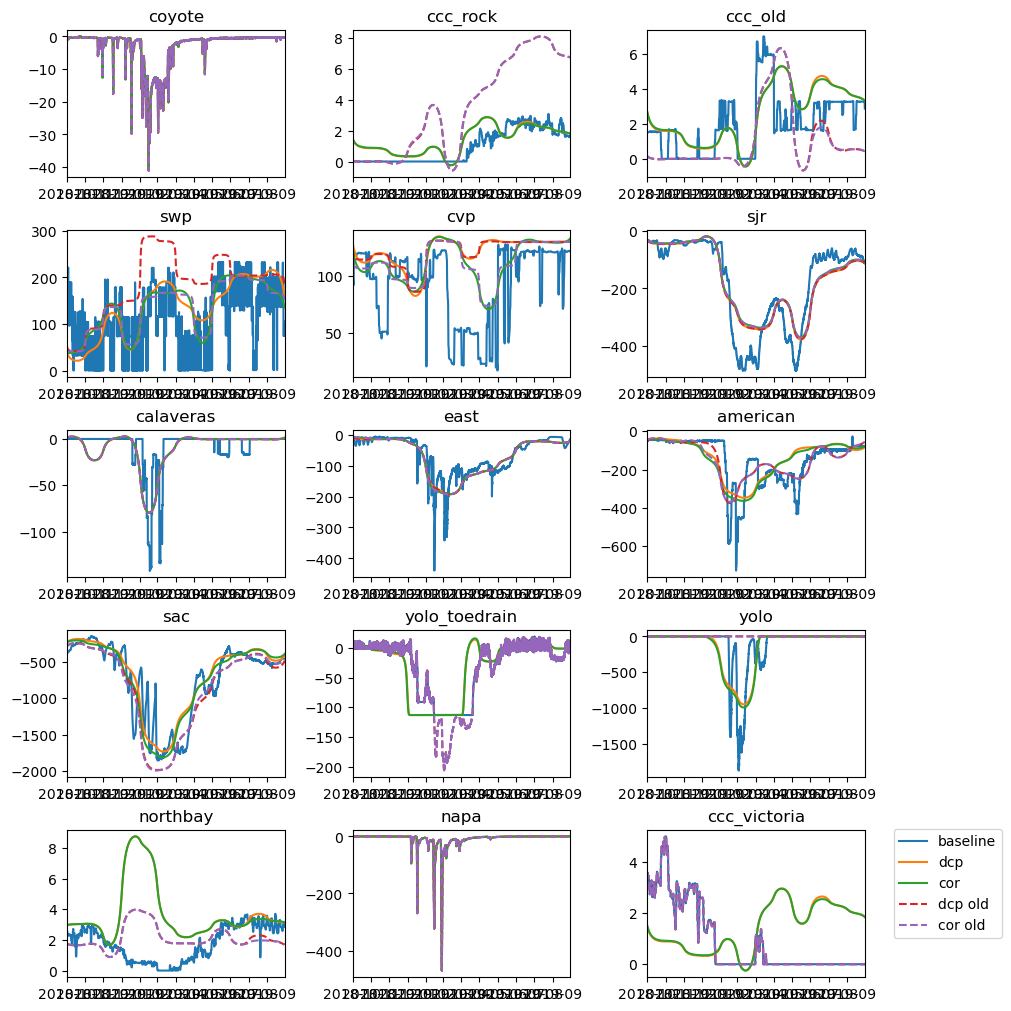

In [8]:
fig = plt.figure(layout='constrained',figsize=(10,10))
count=1
sdate=pd.to_datetime("2018-10-1")
edate=pd.to_datetime("2019-9-30")
for col in base.columns:
    ax = fig.add_subplot(5,3,count)
    plt.plot(base[col][sdate:edate],label='baseline')
    plt.plot(dcp[col][sdate:edate],label='dcp')
    plt.plot(cor[col][sdate:edate],label='cor')
    plt.plot(dcp_old[col][sdate:edate],linestyle='--',label='dcp old')
    plt.plot(cor_old[col][sdate:edate],linestyle='--',label='cor old')
    plt.title(col)
    ax.set_xlim(sdate,edate)
    count=count+1

ax.legend(bbox_to_anchor=(1.1, 1.05))
plt.show()

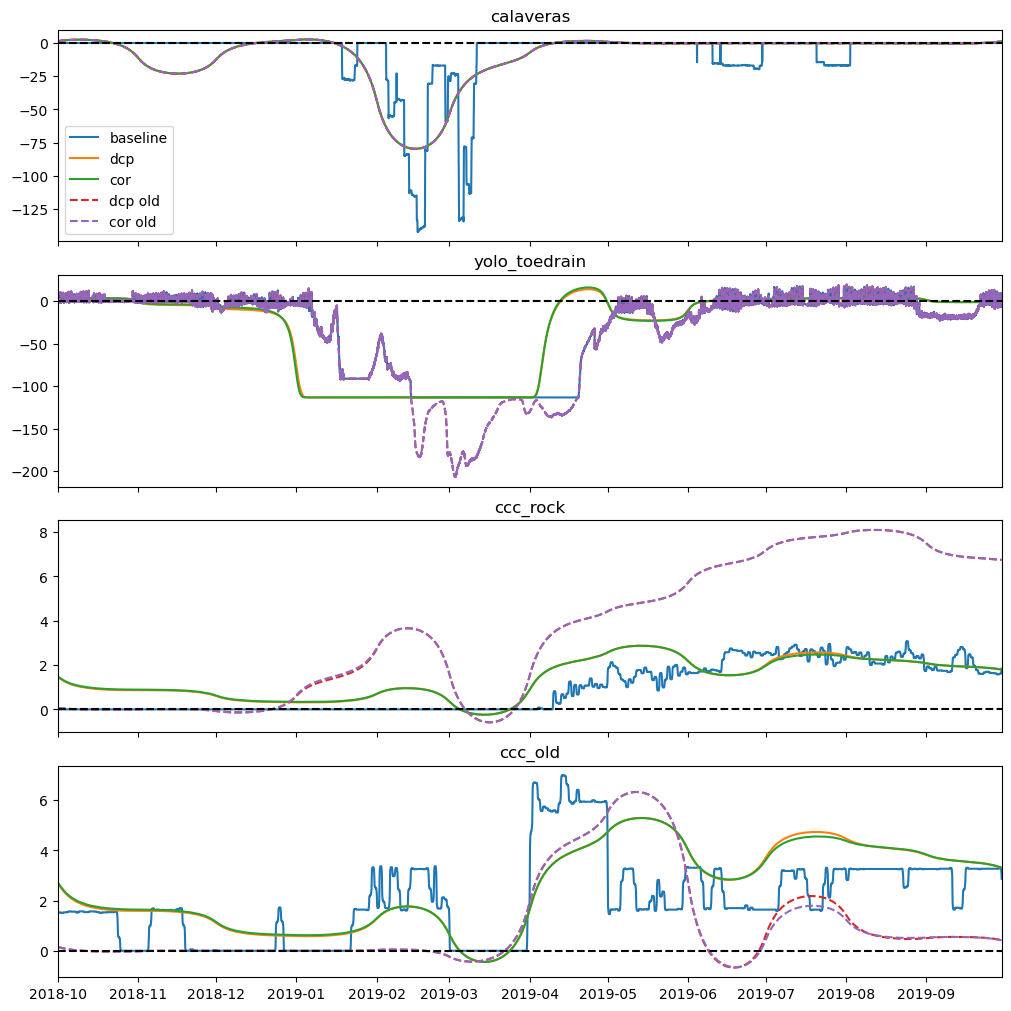

In [23]:
# plot calaveras and toe drain
fig, ax = plt.subplots(4,layout='constrained',sharex=True,figsize=(10,10))

ax[0].plot(base['calaveras'][sdate:edate],label='baseline')
ax[0].plot(dcp['calaveras'][sdate:edate],label='dcp')
ax[0].plot(cor['calaveras'][sdate:edate],label='cor')
ax[0].plot(dcp_old['calaveras'][sdate:edate],linestyle='--',label='dcp old')
ax[0].plot(cor_old['calaveras'][sdate:edate],linestyle='--',label='cor old')
ax[0].set_title('calaveras')
ax[0].set_xlim(sdate,edate)

ax[1].plot(base['yolo_toedrain'][sdate:edate],label='baseline')
ax[1].plot(dcp['yolo_toedrain'][sdate:edate],label='dcp')
ax[1].plot(cor['yolo_toedrain'][sdate:edate],label='cor')
ax[1].plot(dcp_old['yolo_toedrain'][sdate:edate],linestyle='--',label='dcp old')
ax[1].plot(cor_old['yolo_toedrain'][sdate:edate],linestyle='--',label='cor old')
ax[1].set_title('yolo_toedrain')

ax[2].plot(base['ccc_rock'][sdate:edate],label='baseline')
ax[2].plot(dcp['ccc_rock'][sdate:edate],label='dcp')
ax[2].plot(cor['ccc_rock'][sdate:edate],label='cor')
ax[2].plot(dcp_old['ccc_rock'][sdate:edate],linestyle='--',label='dcp old')
ax[2].plot(cor_old['ccc_rock'][sdate:edate],linestyle='--',label='cor old')
ax[2].set_title('ccc_rock')

ax[3].plot(base['ccc_old'][sdate:edate],label='baseline')
ax[3].plot(dcp['ccc_old'][sdate:edate],label='dcp')
ax[3].plot(cor['ccc_old'][sdate:edate],label='cor')
ax[3].plot(dcp_old['ccc_old'][sdate:edate],linestyle='--',label='dcp old')
ax[3].plot(cor_old['ccc_old'][sdate:edate],linestyle='--',label='cor old')
ax[3].set_title('ccc_old')

ax[0].legend()
ax[0].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
ax[1].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
ax[2].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
ax[3].hlines(y=0, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--')
plt.show()
#fig.savefig('./figures/new_boundary_porter_run_2026_04_22.png')

In [ ]:
fig, ax = plt.subplots(2,layout='constrained',sharex=True)

ax.plot(base['calaveras'][sdate:edate],label='baseline')
ax.plot(dcp['calaveras'][sdate:edate],label='dcp')
ax.plot(cor['calaveras'][sdate:edate],label='cor')
ax.plot(dcp_old['calaveras'][sdate:edate],linestyle='--',label='dcp old')
ax.plot(cor_old['calaveras'][sdate:edate],linestyle='--',label='cor old')
ax.set_title('calaveras')
ax.set_xlim(sdate,edate)

In [3]:
# are the salinities and temperatures the same?
bases = pd.read_csv('/home/jisrael/BayDeltaSCHISM/data/time_history/salt.th',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
baset = pd.read_csv('/home/jisrael/BayDeltaSCHISM/data/time_history/temp.th',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
dcps = pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/data/time_history/salt_s0065.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
dcpt = pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/DCP/data/time_history/temp_s0065.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
cors = pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/reserves/data/time_history/salt_s0044.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
cort = pd.read_csv('/home/jisrael/Savio_scratch_back_up/scenario_files/reserves/data/time_history/temp_s0044.th.ported',sep=r'\s+',parse_dates=["datetime"],dtype=np.float32).set_index(["datetime"])
cort

,coyote,sjr,calaveras,east,american,sac,yolo_toedrain,yolo,napa
datetime,,,,,,,,,
2017-01-01 00:00:00,8.6,7.8,8.6,8.6,8.6,8.7,7.5,7.5,8.6
2017-01-01 00:15:00,8.6,7.8,8.6,8.6,8.6,8.7,7.5,7.5,8.6
2017-01-01 00:30:00,8.6,7.8,8.6,8.6,8.6,8.8,7.5,7.5,8.6
2017-01-01 00:45:00,8.5,7.8,8.5,8.5,8.5,8.8,7.5,7.5,8.5
2017-01-01 01:00:00,8.5,7.8,8.5,8.5,8.5,8.8,7.5,7.5,8.5
...,...,...,...,...,...,...,...,...,...
2021-12-31 23:00:00,9.2,9.1,9.2,9.2,9.2,7.3,7.9,7.9,9.2
2021-12-31 23:15:00,9.1,9.1,9.1,9.1,9.1,8.3,7.9,7.9,9.1
2021-12-31 23:30:00,9.1,9.1,9.1,9.1,9.1,8.3,7.9,7.9,9.1
